In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt


In [6]:
def get_relu(mb: torch.Tensor):
    def f(x: torch.Tensor):
        y = mb[0] * x + mb[1]
        return torch.clip(y, min=0)
    return f


In [7]:
from ipywidgets.widgets import interact
@interact(m=1.1, b=1.1)
def relu_plot(m, b):
    f = get_relu(torch.tensor([m, b]))
    x = torch.linspace(-5, 5, 50)
    y = f(x)
    plt.plot(x, y)

interactive(children=(FloatSlider(value=1.1, description='m', max=3.3000000000000003, min=-1.1), FloatSlider(v…

In [12]:
from ipywidgets.widgets import interact
@interact(m1=1.1, b1=1.1, m2=1.1, b2=1.1, m3=1.1, b3=1.1)
def relu_plot_3(m1, b1, m2, b2, m3, b3):
    f1 = get_relu(torch.tensor([m1, b1]))
    f2 = get_relu(torch.tensor([m2, b2]))
    f3 = get_relu(torch.tensor([m3, b3]))
    x = torch.linspace(-5, 5, 50)
    y = f1(x) + f2(x) + f3(x)
    plt.plot(x, y, label="y")
    plt.plot(x, f1(x), color="green", label="f1")
    plt.plot(x, f2(x), color="red", label="f2")
    plt.plot(x, f3(x), color="purple", label="f3")
    plt.legend()


interactive(children=(FloatSlider(value=1.1, description='m1', max=3.3000000000000003, min=-1.1), FloatSlider(…

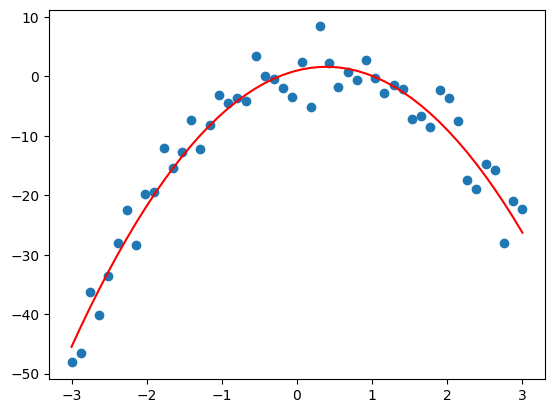

In [25]:
def make_polynomial(coeffs: torch.Tensor):
    # Using Horner's method
    def f(x: torch.Tensor):
        y = torch.tensor(0.0)
        for coeff in coeffs:
            y = y * x + coeff
        return y
    return f
# Add noise to the points using normal distribution and a scaling factor
def noise(x: torch.Tensor, mult: torch.Tensor, add: torch.Tensor):
    return x * (1 + torch.randn(size=x.shape) * mult) + torch.randn(size=x.shape) * add

# Define loss functions

def mae(predicted: torch.Tensor, actual: torch.Tensor):
    return torch.abs(predicted - actual).mean()

def mse(predicted: torch.Tensor, actual: torch.Tensor):
    return torch.square(predicted - actual).mean()

loss_function = mse
np.random.seed(2026)
torch.manual_seed(2026)
f = make_polynomial(torch.tensor([-4.1, 3.2, 1.0]))
x = torch.linspace(-3, 3, 50)
y = noise(f(x), torch.tensor(0.15), torch.tensor(3.1))
plt.scatter(x, y)
plt.plot(x, f(x), color="red")

In [ ]:
train = torch.stack((x,torch.ones_like(x)), dim=1)

In [47]:
# Example, use 10 ReLUs
# The first row represents the parameters of the m's (weights), and the second are the b values (biases)
# For each ReLU, we have mx + b, so for n relus, there are 2n parameters
# Suppose instead of doing the curve fitting directly (using a single quadratic), we use multiple ReLU function

params = torch.rand((2, 10)) - 0.5


In [48]:
torch.clip(train[0] @ params, 0)

tensor([0.2746, 0.0000, 0.3285, 0.0000, 1.1228, 0.0000, 0.0000, 0.3223, 0.0000,
        0.4396])

In [52]:
predicted = torch.sum(torch.clip(train[0] @ params, 0))

In [53]:
# Actual value:
y[0]

tensor(-48.1376)

In [54]:
loss_function(predicted, y[0])

tensor(2562.9385)

In [55]:
predicted

tensor(2.4879)

In [116]:
# Stochastic gradient descent, no batching, go over each training set one at a time

# Adding an output weight, the third parameter fixes the zero output error

learning_rate = 0.001
epochs = 2000
n_params = 500

np.random.seed(2026)
torch.manual_seed(2026)
# Because some params are negative, it'll lead to dead neurons
# Remove the -0.5
params = torch.rand((3, n_params))
params.requires_grad_()

for j in range(epochs):
    epoch_loss = 0.0
    for i in range(len(train)):
        # predicted = torch.sum(torch.clip(train[i] @ params, 0))
        z = train[i] @ params[:2] # mx + b
        h = torch.relu(z)
        predicted = (params[2] * h).sum() # Add a scaler
        loss = loss_function(predicted, y[i])
        epoch_loss += loss.item()
        loss.backward()
        
        with torch.no_grad():
            params -= params.grad * learning_rate
            params.grad.zero_()
            
        #print(f"item = {i}, loss = {loss}", end=", ")

    print("====")
    print(f"epoch = {j}, loss = {epoch_loss}")
params = params.detach()

====
epoch = 0, loss = 193804.37921142578
====
epoch = 1, loss = 16847.302566580474
====
epoch = 2, loss = 1168.7774077914655
====
epoch = 3, loss = 1212.469301871024
====
epoch = 4, loss = 1117.9198541519145
====
epoch = 5, loss = 1034.4918777546845
====
epoch = 6, loss = 977.3595902761444
====
epoch = 7, loss = 938.5180970709771
====
epoch = 8, loss = 911.2987000978319
====
epoch = 9, loss = 891.1231462489814
====
epoch = 10, loss = 875.185862166807
====
epoch = 11, loss = 862.3761673355475
====
epoch = 12, loss = 851.6279694027617
====
epoch = 13, loss = 842.1797502497211
====
epoch = 14, loss = 834.0823072176427
====
epoch = 15, loss = 828.3881555655971
====
epoch = 16, loss = 823.0362339040003
====
epoch = 17, loss = 818.3389896349981
====
epoch = 18, loss = 813.6818054916803
====
epoch = 19, loss = 809.0647868015221
====
epoch = 20, loss = 804.6601740242913
====
epoch = 21, loss = 800.4699871798512
====
epoch = 22, loss = 796.6088395165607
====
epoch = 23, loss = 792.531285638600

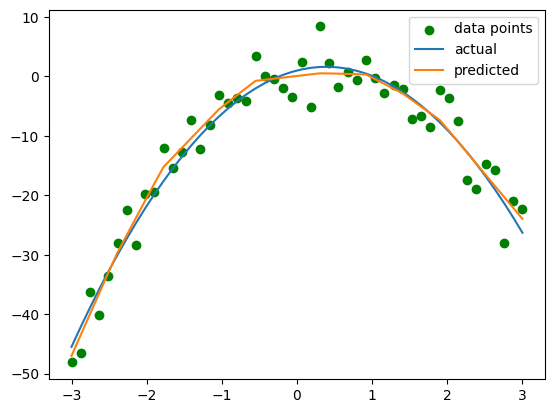

In [117]:
def plot_params():
    x = torch.linspace(-3, 3, 50)
    X = torch.stack((x,torch.ones_like(x)), dim=1)
    
    z = X @ params[:2]
    h = torch.relu(z)
    predicted = (params[2] *h).sum(dim=1)
    plt.scatter(x, y, label="data points", color="green")
    plt.plot(x, f(x), label="actual")
    plt.plot(x, predicted, label="predicted")
    plt.legend()
    plt.show()

plot_params()